In [2]:
#import necessary modules
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

#import CSVs as panda dataframes
observations = pd.read_csv('observations.csv')
species_info = pd.read_csv('species_info.csv')

#inspect dataframes
print(observations.head())
print(species_info.head())

            scientific_name                            park_name  observations
0        Vicia benghalensis  Great Smoky Mountains National Park            68
1            Neovison vison  Great Smoky Mountains National Park            77
2         Prunus subcordata               Yosemite National Park           138
3      Abutilon theophrasti                  Bryce National Park            84
4  Githopsis specularioides  Great Smoky Mountains National Park            85
  category                scientific_name  \
0   Mammal  Clethrionomys gapperi gapperi   
1   Mammal                      Bos bison   
2   Mammal                     Bos taurus   
3   Mammal                     Ovis aries   
4   Mammal                 Cervus elaphus   

                                        common_names conservation_status  
0                           Gapper's Red-Backed Vole                 NaN  
1                              American Bison, Bison                 NaN  
2  Aurochs, Aurochs, Domestic 

Let's dive deeper into exploring each dataframe. First up is observations!

### Observations Dataframe Shape

In [5]:
#what is the size and type of the data?
print(observations.shape)
print(observations.columns)
print(observations.isna().sum())
print(observations.dtypes)

(23296, 3)
Index(['scientific_name', 'park_name', 'observations'], dtype='object')
scientific_name    0
park_name          0
observations       0
dtype: int64
scientific_name    object
park_name          object
observations        int64
dtype: object


The table has 3 columns named 'scientific_name', 'park_name', and 'observations'. There are 23,296 rows with no null values in any of the columns. All column data types are appropriate for the data contained within. This appears to be a tidy dataset. Let's dig deeper!

In [7]:
#Parks in the dataset:
print(f'National parks in the dataset: {observations.park_name.unique()}' + '\n')

#Number of different species:
print(f'Number of species observed across all parks: {observations.scientific_name.nunique()}' + '\n')

#Number of observations per park:
print(f'Number of observations per park:\n {observations.groupby('park_name').observations.sum()}' + '\n')

#Number of unique species observed per park:
print(f'Number of unique species observed per park:\n {observations.groupby('park_name').scientific_name.nunique()}' + '\n')

#Total number of observations across all parks:
print(f'Total number of observations across all parks: {observations.observations.sum()}')

National parks in the dataset: ['Great Smoky Mountains National Park' 'Yosemite National Park'
 'Bryce National Park' 'Yellowstone National Park']

Number of species observed across all parks: 5541

Number of observations per park:
 park_name
Bryce National Park                     576025
Great Smoky Mountains National Park     431820
Yellowstone National Park              1443562
Yosemite National Park                  863332
Name: observations, dtype: int64

Number of unique species observed per park:
 park_name
Bryce National Park                    5541
Great Smoky Mountains National Park    5541
Yellowstone National Park              5541
Yosemite National Park                 5541
Name: scientific_name, dtype: int64

Total number of observations across all parks: 3314739


There are four national parks in this data set: Yellowstone, Bryce, Great Smoky Mountains, and Yosemite. Across all four parks, 5,541 unique species were observed 3,314,739 times in the last 7 days. Somewhat strangely, the number of unique species observed at each park matched the exact number of unique species observed across all parks. Let's investigate why this might be by sorting the dataframe by scientific name to see if any patterns emerge.

In [9]:
observations = observations.sort_values('scientific_name')
print(observations.head(20))

            scientific_name                            park_name  observations
8050          Abies bifolia            Yellowstone National Park           215
4968          Abies bifolia                  Bryce National Park           109
17990         Abies bifolia  Great Smoky Mountains National Park            72
20930         Abies bifolia               Yosemite National Park           136
4647         Abies concolor  Great Smoky Mountains National Park           101
15193        Abies concolor            Yellowstone National Park           241
23166        Abies concolor               Yosemite National Park           205
8170         Abies concolor                  Bryce National Park            83
2014          Abies fraseri                  Bryce National Park           109
11141         Abies fraseri            Yellowstone National Park           218
5793          Abies fraseri               Yosemite National Park           110
5112          Abies fraseri  Great Smoky Mountains N

Sorting shows that this dataset is actually tracking the number of observations of the same 5,541 species in each park. With this in mind, let's see the 5 most observed species and the 5 least observed species across the parks!

In [11]:
top5 = observations.groupby('scientific_name').observations.sum().sort_values(ascending=False)
bottom5 = top5.sort_values(ascending=True)
print(f'Top 5 Most Observed Species:\n {top5.head(5)}' + '\n')
print(f'5 Rarest Observed Species:\n {bottom5.head(5)}')

Top 5 Most Observed Species:
 scientific_name
Streptopelia decaocto    1785
Holcus lanatus           1780
Castor canadensis        1725
Hypochaeris radicata     1720
Puma concolor            1711
Name: observations, dtype: int64

5 Rarest Observed Species:
 scientific_name
Grus americana         131
Canis rufus            137
Vermivora bachmanii    141
Noturus baileyi        143
Rana sierrae           144
Name: observations, dtype: int64


Ok, let's leave that dataset alone now and switch focus to the species_info dataset for a bit!

### Species_Info Dataset

In [14]:
#what is the size and type of the data?
print(species_info.shape)
print(species_info.columns)
print(species_info.isna().sum())
print(species_info.dtypes)

(5824, 4)
Index(['category', 'scientific_name', 'common_names', 'conservation_status'], dtype='object')
category                  0
scientific_name           0
common_names              0
conservation_status    5633
dtype: int64
category               object
scientific_name        object
common_names           object
conservation_status    object
dtype: object


This dataset contains 5,824 rows with 4 columns: 'category', 'scientific_name', 'common_names', and 'conservation_status'. Of these 4, conservation_status has quite a few null values. Let's look further.

In [16]:
print(species_info.conservation_status.unique())

[nan 'Species of Concern' 'Endangered' 'Threatened' 'In Recovery']


This column appears to only mark species under some sort of protection. Accordingly, it makes sense that the value will be null if the species listed does not have a protected status. In order to aid with data analysis, let's change these NaN values to "Not Protected". Let's also see what the breakdown of each status is.

In [18]:
species_info = species_info.fillna(value={'conservation_status': 'Not Protected'})
print(f'Breakdown of Conservation Statuses: {species_info.groupby('conservation_status').size()}')

Breakdown of Conservation Statuses: conservation_status
Endangered              16
In Recovery              4
Not Protected         5633
Species of Concern     161
Threatened              10
dtype: int64


Another observation of note is the number of species. This dataset contains 5,824 entries. Our other dataset only contained 5,541 species. Accordingly, it's worth seeing if there are multiple rows for a single scientific name in the species info dataset.

In [20]:
print(species_info.duplicated(subset='scientific_name').value_counts())

False    5541
True      283
Name: count, dtype: int64


Looks like we have 283 repeated species. Let's merge these rows into one single row.

In [22]:
def join_unique(items):
    return ', '.join(set(items))
species_info = species_info.groupby(['scientific_name']).agg({'category': join_unique, 'common_names': join_unique, 'conservation_status': join_unique}).reset_index()
print(species_info.duplicated(subset='scientific_name').value_counts())

False    5541
Name: count, dtype: int64


No more duplicate rows! This will make cross-referencing the two datasets easier and cleaner. Let's look to see what categories of species there are to observe and what their distribution is.

In [24]:
print(species_info.category.unique())
print(f'Breakdown of categories: {species_info.groupby('category').size()}')

['Vascular Plant' 'Nonvascular Plant' 'Bird' 'Amphibian' 'Reptile'
 'Mammal' 'Fish']
Breakdown of categories: category
Amphibian              79
Bird                  488
Fish                  125
Mammal                176
Nonvascular Plant     333
Reptile                78
Vascular Plant       4262
dtype: int64


A noticeable attribute of these two datasets is the shared column of 'scientific_name'. Accordingly, it may make sense to utilize scientific_name as a join key to merge these tables into one so we can more easily breakdown observation information by attributes like species category or species common name.

In [26]:
#print most common and most rare list by common name
#merge dataframes using inner join on 'scientific_name'
obs_and_species = pd.merge(observations, species_info, how='left', on='scientific_name')
print(obs_and_species.head(5))
print(obs_and_species.shape)
print(obs_and_species.isna().sum())

  scientific_name                            park_name  observations  \
0   Abies bifolia            Yellowstone National Park           215   
1   Abies bifolia                  Bryce National Park           109   
2   Abies bifolia  Great Smoky Mountains National Park            72   
3   Abies bifolia               Yosemite National Park           136   
4  Abies concolor  Great Smoky Mountains National Park           101   

         category                                       common_names  \
0  Vascular Plant                          Rocky Mountain Alpine Fir   
1  Vascular Plant                          Rocky Mountain Alpine Fir   
2  Vascular Plant                          Rocky Mountain Alpine Fir   
3  Vascular Plant                          Rocky Mountain Alpine Fir   
4  Vascular Plant  Balsam Fir, Colorado Fir, Concolor Fir, Silver...   

  conservation_status  
0       Not Protected  
1       Not Protected  
2       Not Protected  
3       Not Protected  
4       Not Pr

### Let's make some Data Visualizations!

First up...observations! Let's see a bar chart of the total number of observations by park.

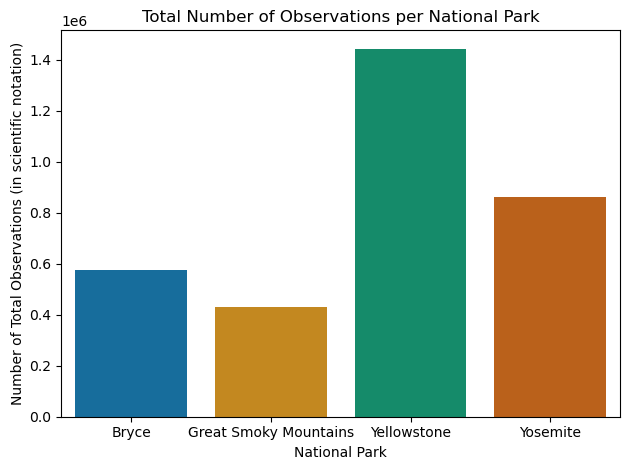

<Figure size 640x480 with 0 Axes>

In [29]:
#number of observations by park
obs_by_park = observations.groupby('park_name').observations.sum().reset_index()
obs_by_park['park_name'] = obs_by_park['park_name'].str.replace(' National Park', '')
ax = sns.barplot(data=obs_by_park, x='park_name', y='observations', hue='park_name', palette='colorblind', legend=False)
ax.set(title='Total Number of Observations per National Park', xlabel='National Park', ylabel='Number of Total Observations (in scientific notation)')
plt.tight_layout()
plt.show()
plt.clf()

Next let's see a breakdown of the total number of observations per species category, as specified in the species_info dataset.

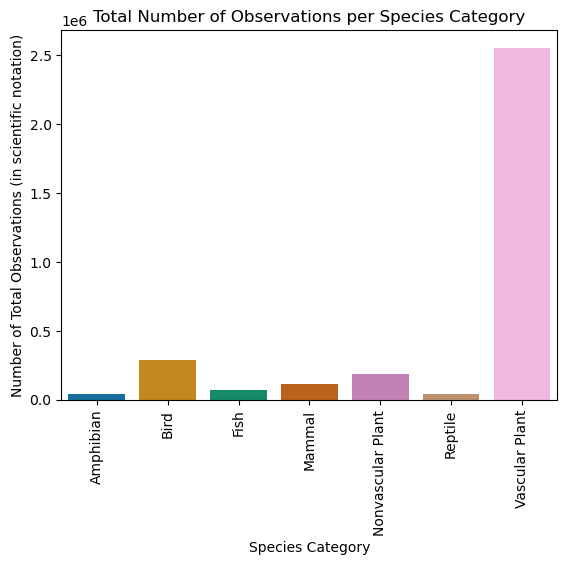

<Figure size 640x480 with 0 Axes>

In [31]:
obs_by_species = obs_and_species.groupby('category').observations.sum().reset_index()
ax = sns.barplot(data=obs_by_species, x='category', y='observations', hue='category', palette='colorblind', legend=False)
ax.set(title='Total Number of Observations per Species Category', xlabel='Species Category', ylabel='Number of Total Observations (in scientific notation)')
plt.xticks(rotation=90)
plt.show()
plt.clf()

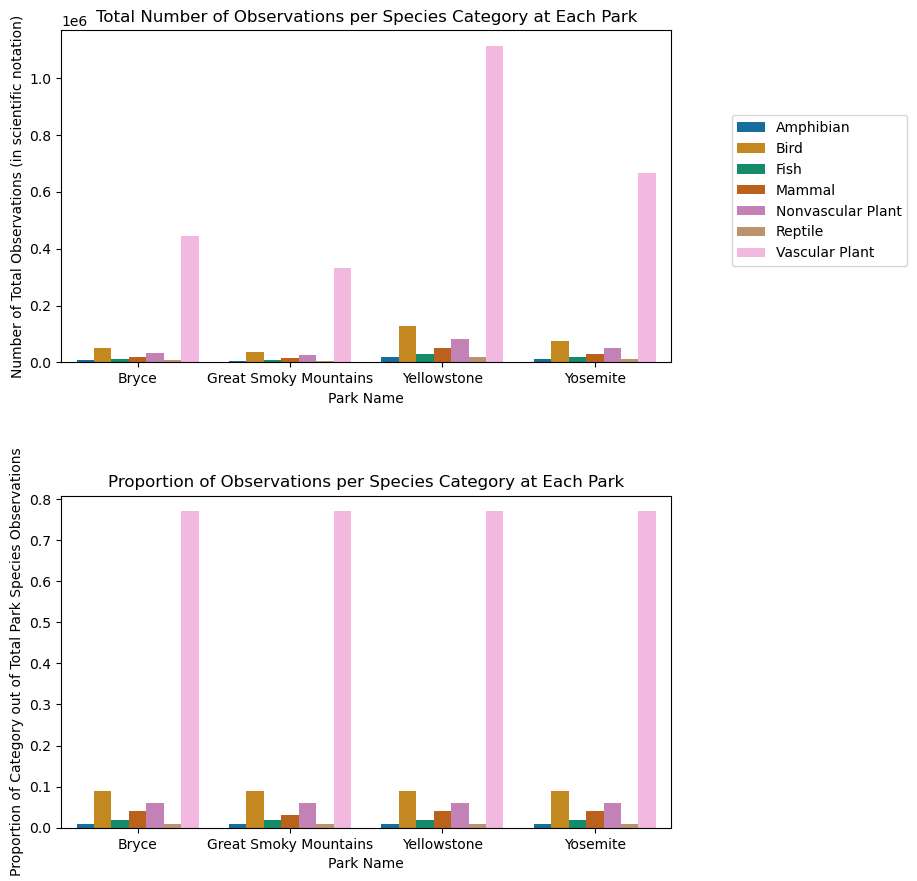

<Figure size 640x480 with 0 Axes>

In [32]:
#counts of observations of species per category by park
category_counts = obs_and_species.groupby(['park_name', 'category']).observations.sum().reset_index()
category_counts['park_name'] = category_counts['park_name'].str.replace(' National Park', '')

#categories proportionally by park
category_counts['prop_park'] = round(category_counts['observations'] / category_counts.groupby('park_name')['observations'].transform('sum'), 2)

#graph each
fig, axes = plt.subplots(2, 1, figsize=(8,10))
plt.subplots_adjust(wspace=1)

axes[0] = sns.barplot(data=category_counts, x='park_name', y='observations', hue='category', palette='colorblind', legend=True, ax=axes[0])
axes[0].set(title='Total Number of Observations per Species Category at Each Park', xlabel='Park Name', ylabel='Number of Total Observations (in scientific notation)')
axes[1] = sns.barplot(data=category_counts, x='park_name', y='prop_park', hue='category', palette='colorblind', legend=True, ax=axes[1])
axes[1].set(title='Proportion of Observations per Species Category at Each Park', xlabel='Park Name', ylabel='Proportion of Category out of Total Park Species Observations')
plt.tight_layout(pad=5)

#make one legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.98, 0.75))
axes[0].get_legend().remove()
axes[1].get_legend().remove()

plt.show()
plt.clf()

As the graphs demonstrate, the majority (~75%) of all species observed, both overall and at each individual park, are vascular plants. However, people often flock to national parks to see something that is out of the ordinary. Since Yellowstone has the most species observations, let's use chi-square testing to see if there is a statisically significant difference in the number of observations of protected species at Yellowstone as opposed to other parks.

In [34]:
#we first need to aggregate some data in order to create our contingency tables
#specifically, we need to know the breakdown of observations per park by whether the species is protected or not
#add new column to make summing the number of protected species easier
obs_and_species['protected'] = obs_and_species.conservation_status != 'Not Protected'
protected_species_per_park = obs_and_species.groupby(['park_name', 'protected']).observations.sum().reset_index()
print(protected_species_per_park)

                             park_name  protected  observations
0                  Bryce National Park      False        559762
1                  Bryce National Park       True         16263
2  Great Smoky Mountains National Park      False        420543
3  Great Smoky Mountains National Park       True         11277
4            Yellowstone National Park      False       1404527
5            Yellowstone National Park       True         39035
6               Yosemite National Park      False        839799
7               Yosemite National Park       True         23533


In terms of absolute numbers, it's no surprise that Yellowstone has the highest number of protected species observed. Let's see if this number is statistically significant from the other parks using chi-square testing.

In [36]:
from scipy.stats import chi2_contingency
#create contingency tables

#create list of parks to iterate through
parks = protected_species_per_park.park_name.unique().tolist()
#remove Yellowstone since we don't need to compare Yellowstone to itself
yellowstone = 'Yellowstone National Park'
parks.remove(yellowstone)

#create dict to store pval of chi-square test for each park pairing
pval_dict = {}
#create yellowstone contingency table
yellowstone_table = [protected_species_per_park.loc[(protected_species_per_park.park_name == yellowstone) & (protected_species_per_park.protected == True), 'observations'].item(),
                     protected_species_per_park.loc[(protected_species_per_park.park_name == yellowstone) & (protected_species_per_park.protected == False), 'observations'].item()]

#iterate through the 3 other parks to create contingency table and calculate pval for each park pairing
for park in parks:
    table = [[],[]]
    #park_value for protected species observations
    table[0].append(protected_species_per_park.loc[(protected_species_per_park.park_name == park) & (protected_species_per_park.protected == True), 'observations'].item())
    #park_value for NOT protected species observations
    table[0].append(protected_species_per_park.loc[(protected_species_per_park.park_name == park) & (protected_species_per_park.protected == False), 'observations'].item())
    table[1] = yellowstone_table
    chi2, pval, dof, expected = chi2_contingency(table)
    pval_dict[park] = pval
print(pval_dict)

{'Bryce National Park': 2.8170850473627204e-06, 'Great Smoky Mountains National Park': 0.0009750004546326975, 'Yosemite National Park': 0.3268985967028068}


As we can see the p-values for both Bryce and the Great Smoky Mountains is less than 0.05 meaning there is a statistically significant difference in the number of protected species observed at Yellowstone as compared to the other two parks. However, the p-val for the chi-square analysis for Yosemite and Yellowstone is about 0.33, meaning there is no statistically significant difference in the number of protected species observed at each park. 

Let's see if there's a statistically significant difference between Yosemite and the other two parks.

In [57]:
#remove Yosemite since we don't need to compare Yosemite to itself
yosemite = 'Yosemite National Park'
parks.remove(yosemite)

#create dict to store pval of chi-square test for each park pairing
pval_dict = {}
#create yosemitee contingency table
yosemite_table = [protected_species_per_park.loc[(protected_species_per_park.park_name == yosemite) & (protected_species_per_park.protected == True), 'observations'].item(),
                     protected_species_per_park.loc[(protected_species_per_park.park_name == yosemite) & (protected_species_per_park.protected == False), 'observations'].item()]

#iterate through the 2 other parks to create contingency table and calculate pval for each park pairing
for park in parks:
    table = [[],[]]
    #park_value for protected species observations
    table[0].append(protected_species_per_park.loc[(protected_species_per_park.park_name == park) & (protected_species_per_park.protected == True), 'observations'].item())
    #park_value for NOT protected species observations
    table[0].append(protected_species_per_park.loc[(protected_species_per_park.park_name == park) & (protected_species_per_park.protected == False), 'observations'].item())
    table[1] = yosemite_table
    chi2, pval, dof, expected = chi2_contingency(table)
    pval_dict[park] = pval
print(pval_dict)

{'Bryce National Park': 0.000484097535863521, 'Great Smoky Mountains National Park': 0.0001524384183962306}


These p-values are well below the standard threshold of 0.05, meaning the number of observations of protected species at Yosemite is statistically significantly different than either Bryce or Great Smoky Mountains. Accordingly, if we were hoping to see a protected species and were trying to decide which of the 4 parks to visit, either Yosemite or Yellowstone would be our best bet!